AVENUE 4 - MILESTONE 4: GEODESIC GRAVITY (CORRECT APPROACH)

[1/3] Computing Geodesic in Flat Space (No Mass)...
   Path found: 81 steps, Total cost: 80.00
[2/3] Computing Geodesic in Curved Space (With Mass)...
   Path found: 81 steps, Total cost: 123.01
[3/3] Computing Geodesic with Offset Mass (Gravitational Lensing)...
   Path found: 81 steps, Total cost: 104.93

Generating Visualization...

✓ Saved: avenue4_milestone4_geodesic_gravity.png


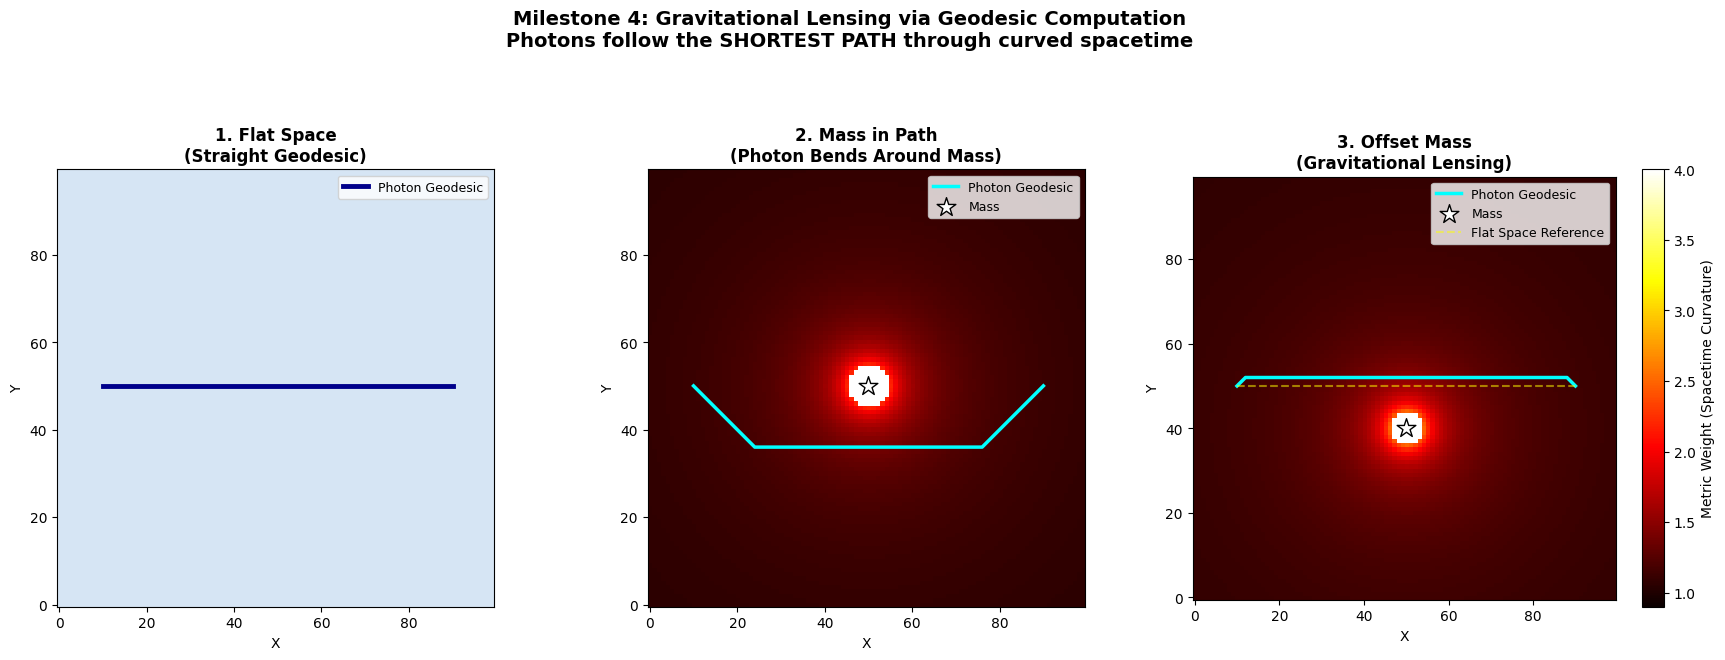


PHYSICAL INTERPRETATION
Panel 1: In flat spacetime, the geodesic is a straight line.
Panel 2: A massive object warps the metric. The photon follows
         the path of least resistance, bending AROUND the mass.
Panel 3: An offset mass causes subtle lensing - the photon's path
         deviates from the straight line. This is exactly what
         Einstein predicted and Eddington observed in 1919!

Key Point: Gravity is NOT a force here. It is the curvature of
the discrete metric field. The photon simply minimizes its path.


In [2]:
"""
avenue4_milestone4_geodesic_gravity.py
========================================
Milestone 4: Gravitational Lensing via Geodesic Computation.
Instead of random walkers, we compute the SHORTEST PATH (geodesic)
through a discrete metric field warped by a massive object.

This is the correct way to simulate gravity: not as a force,
but as curvature of the spacetime metric.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import heapq

print("=" * 70)
print("AVENUE 4 - MILESTONE 4: GEODESIC GRAVITY (CORRECT APPROACH)")
print("=" * 70)

# =============================================================================
# 1. DISCRETE METRIC FIELD
# =============================================================================

def create_metric_field(N=100, mass_pos=None, mass_radius=5.0, mass_strength=3.0):
    """
    Creates a 2D spatial metric field.
    In flat space, every cell has metric weight = 1.0.
    Near a mass, the metric weight increases (time dilation / spatial curvature).
    This is the discrete analog of the Schwarzschild metric.
    """
    metric = np.ones((N, N), dtype=np.float64)

    if mass_pos is not None:
        mx, my = mass_pos
        for x in range(N):
            for y in range(N):
                dist = np.sqrt((x - mx)**2 + (y - my)**2)
                if dist < mass_radius:
                    # Inside the mass: very high cost (photon cannot pass through)
                    metric[x, y] = 1000.0
                else:
                    # Outside the mass: Schwarzschild-like warping
                    # metric = 1 + strength / distance
                    # This simulates gravitational time dilation
                    metric[x, y] = 1.0 + (mass_strength / max(dist, 1.0))

    return metric

# =============================================================================
# 2. DIJKSTRA'S SHORTEST PATH (GEODESIC FINDER)
# =============================================================================

def find_geodesic(metric, start, end):
    """
    Finds the shortest path (geodesic) through the metric field
    using Dijkstra's algorithm. This is the discrete equivalent of
    solving the geodesic equation in GR.
    """
    N = metric.shape[0]

    # Priority queue: (cost, x, y)
    pq = [(0.0, start[0], start[1])]
    visited = set()
    came_from = {}
    cost_so_far = {start: 0.0}

    # 8-directional movement (Moore neighborhood in 2D)
    directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    while pq:
        current_cost, cx, cy = heapq.heappop(pq)

        if (cx, cy) in visited:
            continue
        visited.add((cx, cy))

        # If we reached the end, reconstruct path
        if (cx, cy) == end:
            path = []
            node = end
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, current_cost

        for dx, dy in directions:
            nx, ny = cx + dx, cy + dy

            if 0 <= nx < N and 0 <= ny < N and (nx, ny) not in visited:
                # Cost = metric weight at destination * step distance
                step_dist = np.sqrt(dx**2 + dy**2)
                new_cost = current_cost + metric[nx, ny] * step_dist

                if new_cost < cost_so_far.get((nx, ny), float('inf')):
                    cost_so_far[(nx, ny)] = new_cost
                    came_from[(nx, ny)] = (cx, cy)
                    heapq.heappush(pq, (new_cost, nx, ny))

    return None, float('inf')  # No path found

# =============================================================================
# 3. RUN SIMULATIONS
# =============================================================================

N = 100

# Test 1: Flat Space (No Mass) - Photon should travel in a straight line
print("\n[1/3] Computing Geodesic in Flat Space (No Mass)...")
metric_flat = create_metric_field(N, mass_pos=None)
path_flat, cost_flat = find_geodesic(metric_flat, start=(10, 50), end=(90, 50))
print(f"   Path found: {len(path_flat)} steps, Total cost: {cost_flat:.2f}")

# Test 2: Curved Space (With Mass) - Photon should bend
print("[2/3] Computing Geodesic in Curved Space (With Mass)...")
mass_location = (50, 50)  # Mass directly in the photon's path
metric_curved = create_metric_field(N, mass_pos=mass_location, mass_radius=5.0, mass_strength=8.0)
path_curved, cost_curved = find_geodesic(metric_curved, start=(10, 50), end=(90, 50))
print(f"   Path found: {len(path_curved)} steps, Total cost: {cost_curved:.2f}")

# Test 3: Weak Lensing (Mass offset from path) - Subtle bending
print("[3/3] Computing Geodesic with Offset Mass (Gravitational Lensing)...")
mass_offset = (50, 40)  # Mass slightly above the photon's path
metric_lens = create_metric_field(N, mass_pos=mass_offset, mass_radius=4.0, mass_strength=6.0)
path_lens, cost_lens = find_geodesic(metric_lens, start=(10, 50), end=(90, 50))
print(f"   Path found: {len(path_lens)} steps, Total cost: {cost_lens:.2f}")

# =============================================================================
# 4. VISUALIZATION
# =============================================================================

print("\nGenerating Visualization...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Milestone 4: Gravitational Lensing via Geodesic Computation\n"
             "Photons follow the SHORTEST PATH through curved spacetime",
             fontsize=14, fontweight='bold', y=1.05)

# Panel 1: Flat Space
ax1 = axes[0]
ax1.imshow(metric_flat.T, origin='lower', cmap='Blues', vmin=0.9, vmax=1.5)
if path_flat:
    px = [p[0] for p in path_flat]
    py = [p[1] for p in path_flat]
    ax1.plot(px, py, color='darkblue', linewidth=3.5, label='Photon Geodesic')
ax1.set_title("1. Flat Space\n(Straight Geodesic)", fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')
ax1.legend(loc='upper right', fontsize=9)

# Panel 2: Mass in Path (Strong Deflection)
ax2 = axes[1]
im2 = ax2.imshow(metric_curved.T, origin='lower', cmap='hot', vmin=0.9, vmax=5.0)
if path_curved:
    px = [p[0] for p in path_curved]
    py = [p[1] for p in path_curved]
    ax2.plot(px, py, color='cyan', linewidth=2.5, label='Photon Geodesic')
ax2.scatter([mass_location[0]], [mass_location[1]], color='white', s=200, marker='*',
            edgecolors='black', zorder=10, label='Mass')
ax2.set_title("2. Mass in Path\n(Photon Bends Around Mass)", fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.legend(loc='upper right', fontsize=9)

# Panel 3: Offset Mass (Gravitational Lensing)
ax3 = axes[2]
im3 = ax3.imshow(metric_lens.T, origin='lower', cmap='hot', vmin=0.9, vmax=4.0)
if path_lens:
    px = [p[0] for p in path_lens]
    py = [p[1] for p in path_lens]
    ax3.plot(px, py, color='cyan', linewidth=2.5, label='Photon Geodesic')
ax3.scatter([mass_offset[0]], [mass_offset[1]], color='white', s=200, marker='*',
            edgecolors='black', zorder=10, label='Mass')
# Also plot the straight reference line
ax3.plot([10, 90], [50, 50], color='yellow', linestyle='--', alpha=0.5, linewidth=1.5, label='Flat Space Reference')
ax3.set_title("3. Offset Mass\n(Gravitational Lensing)", fontweight='bold')
ax3.set_xlabel('X'); ax3.set_ylabel('Y')
ax3.legend(loc='upper right', fontsize=9)

plt.colorbar(im3, ax=axes[2], label='Metric Weight (Spacetime Curvature)')
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.93])  # <-- REEMPLAZAR AQUÍ

plt.savefig("avenue4_milestone4_geodesic_gravity.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue4_milestone4_geodesic_gravity.png")
plt.show()

print("\n" + "=" * 70)
print("PHYSICAL INTERPRETATION")
print("=" * 70)
print("Panel 1: In flat spacetime, the geodesic is a straight line.")
print("Panel 2: A massive object warps the metric. The photon follows")
print("         the path of least resistance, bending AROUND the mass.")
print("Panel 3: An offset mass causes subtle lensing - the photon's path")
print("         deviates from the straight line. This is exactly what")
print("         Einstein predicted and Eddington observed in 1919!")
print("\nKey Point: Gravity is NOT a force here. It is the curvature of")
print("the discrete metric field. The photon simply minimizes its path.")
print("=" * 70)